In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from matplotlib.ticker import FuncFormatter
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from astropy.visualization import make_lupton_rgb, AsinhStretch, ImageNormalize, simple_norm
from crop import crop
from astropy.wcs.utils import skycoord_to_pixel, proj_plane_pixel_scales
# from hst_phot import *
import matplotlib.patches as patches
from astropy.table import vstack

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift
from src.ifu_tools.run_photometry import download_hst_image, download_spitzer_image, BANDS
import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
lines_of_interest = {
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
}
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

test = ascii.read('../../catalogue_analysis/allsources.csv')
tab = test[test['object_id']!= 'STACK']
SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection = tab[SNR_mask&EW_mask]


In [81]:
cand = selection[selection['object_id']=='22d57m55pt32s-13d37m11pt705s']
galloc = SkyCoord(cand['ra'][0], cand['dec'][0], unit=u.deg)
print(cand['name'])

name
----
a209


In [ ]:
# for band_name, band_info in BANDS.items():
#     query_name, instrument, archive = band_info
#     image_path = None
#     if archive == 'MAST':
#         image_path = download_hst_image(galloc, (query_name, instrument), 'plot')
#     elif archive == 'Spitzer':
#         image_path = download_spitzer_image(galloc, (query_name, instrument), 'plot')

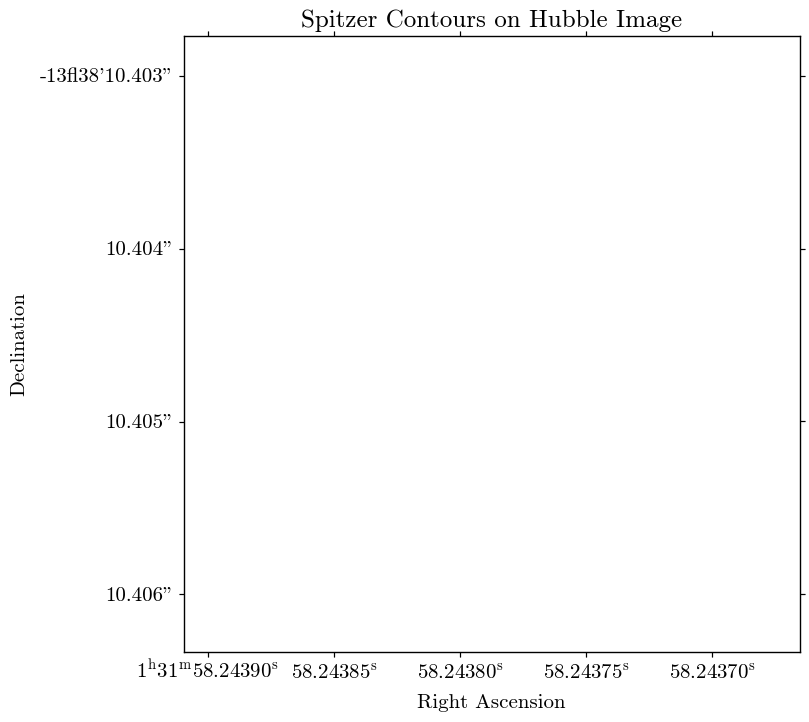

In [ ]:
image_b = fits.open('plot/mastDownload/HLA/hst_12451_b3_wfc3_uvis_f275w_01/hst_12451_b3_wfc3_uvis_f275w_01_drz.fits')
image_g = fits.open('plot/mastDownload/HST/jbtaa3010/jbtaa3010_drc.fits')
image_r = fits.open('plot/mastDownload/HST/hst_12451_a4_wfc3_ir_f160w_ibtaa4qj/hst_12451_a4_wfc3_ir_f160w_ibtaa4qj_drz.fits')

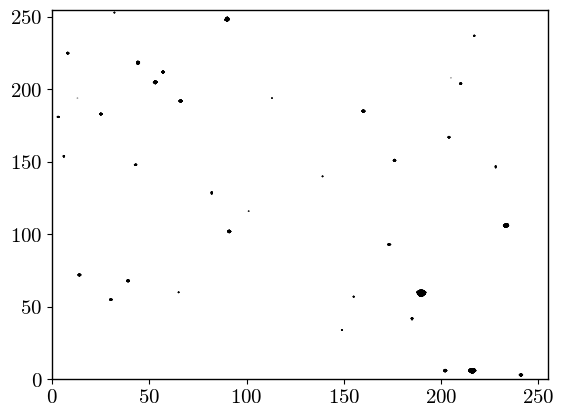

In [ ]:
plt.contour(
    spitzer_data,
    levels=np.logspace(.5, 3, 100), # Example contour levels
    colors='black',
    linewidths=1, zorder=10
)

In [ ]:
spitzer_data

numpy.ndarray

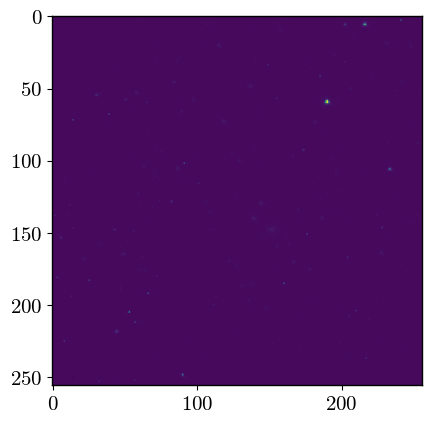

In [43]:
plt.imshow(spitzer_data)

In [49]:
a =fits.open('plot/spitzer_IRAC_1.fits')

In [59]:
a[0].header

SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / FOUR-BYTE SINGLE PRECISION FLOATING POINT      
NAXIS   =                    2 / STANDARD FITS FORMAT                           
NAXIS1  =                  256 / STANDARD FITS FORMAT                           
NAXIS2  =                  256 / STANDARD FITS FORMAT                           
ORIGIN  = 'Spitzer Science Center' / Organization generating this FITS file     
CREATOR = 'S19.2.0 '           / SW version used to create this FITS file       
TELESCOP= 'Spitzer '           / SPITZER Space Telescope                        
INSTRUME= 'IRAC    '           / SPITZER Space Telescope instrument ID          
CHNLNUM =                    1 / 1 digit instrument channel number              
EXPTYPE = 'sci     '           / Exposure Type                                  
REQTYPE = 'AOR     '           / Request type (AOR, IER, or  SER)               
AOT_TYPE= 'IracMapPC'       